In [ ]:
#

# Clone official YOLOv5 repository
!git clone https://github.com/ultralytics/yolov5.git
%cd yolov5


fatal: destination path 'yolov5' already exists and is not an empty directory.
/content/yolov5


In [ ]:
!pip install -r requirements.txt


In [ ]:
!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="CKe86YaLXSTJ3D2DfZRF")
project = rf.workspace("chicken-detection-jjmfp").project("chicken-5f1o9-sbe06")
version = project.version(5)
dataset = version.download("yolov5")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.8/86.8 kB 8.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 13.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.2/4.2 MB 115.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 120.6 MB/s eta 0:00:00
  Attempting uninstall: opencv-python-headless
    Found existing installation: opencv-python-headless 4.11.0.86
    Uninstalling opencv-python-headless-4.11.0.86:
      Successfully uninstalled opencv-python-headless-4.11.0.86
  Attempting uninstall: idna
    Found existing installation: idna 3.10
    Uninstalling idna-3.10:
      Successfully uninstalled idna-3.10
loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to chicken-5 in yolov5pytorch:: 100%|██████████| 21827/21827 [00:06<00:00, 3402.81it/s]


Training the dataset in 50 **epochs**

In [ ]:
!python train.py --img 416 --batch 16 --epochs 75 --data chicken-5/data.yaml --weights yolov5s.pt --cache


wandb: WARNING ⚠️ wandb is deprecated and will be removed in a future release. See supported integrations at https://github.com/ultralytics/yolov5#integrations.
2025-07-09 13:33:21.188691: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1752068001.221108   54168 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1752068001.231259   54168 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
wandb: Enter your choice: (30 second timeout) 
wandb: W&B disabled due to login timeout.
train: weights=yolov5s.pt, cfg=, data=chicken-5/data.yaml, hyp=data/hyps/hyp.s

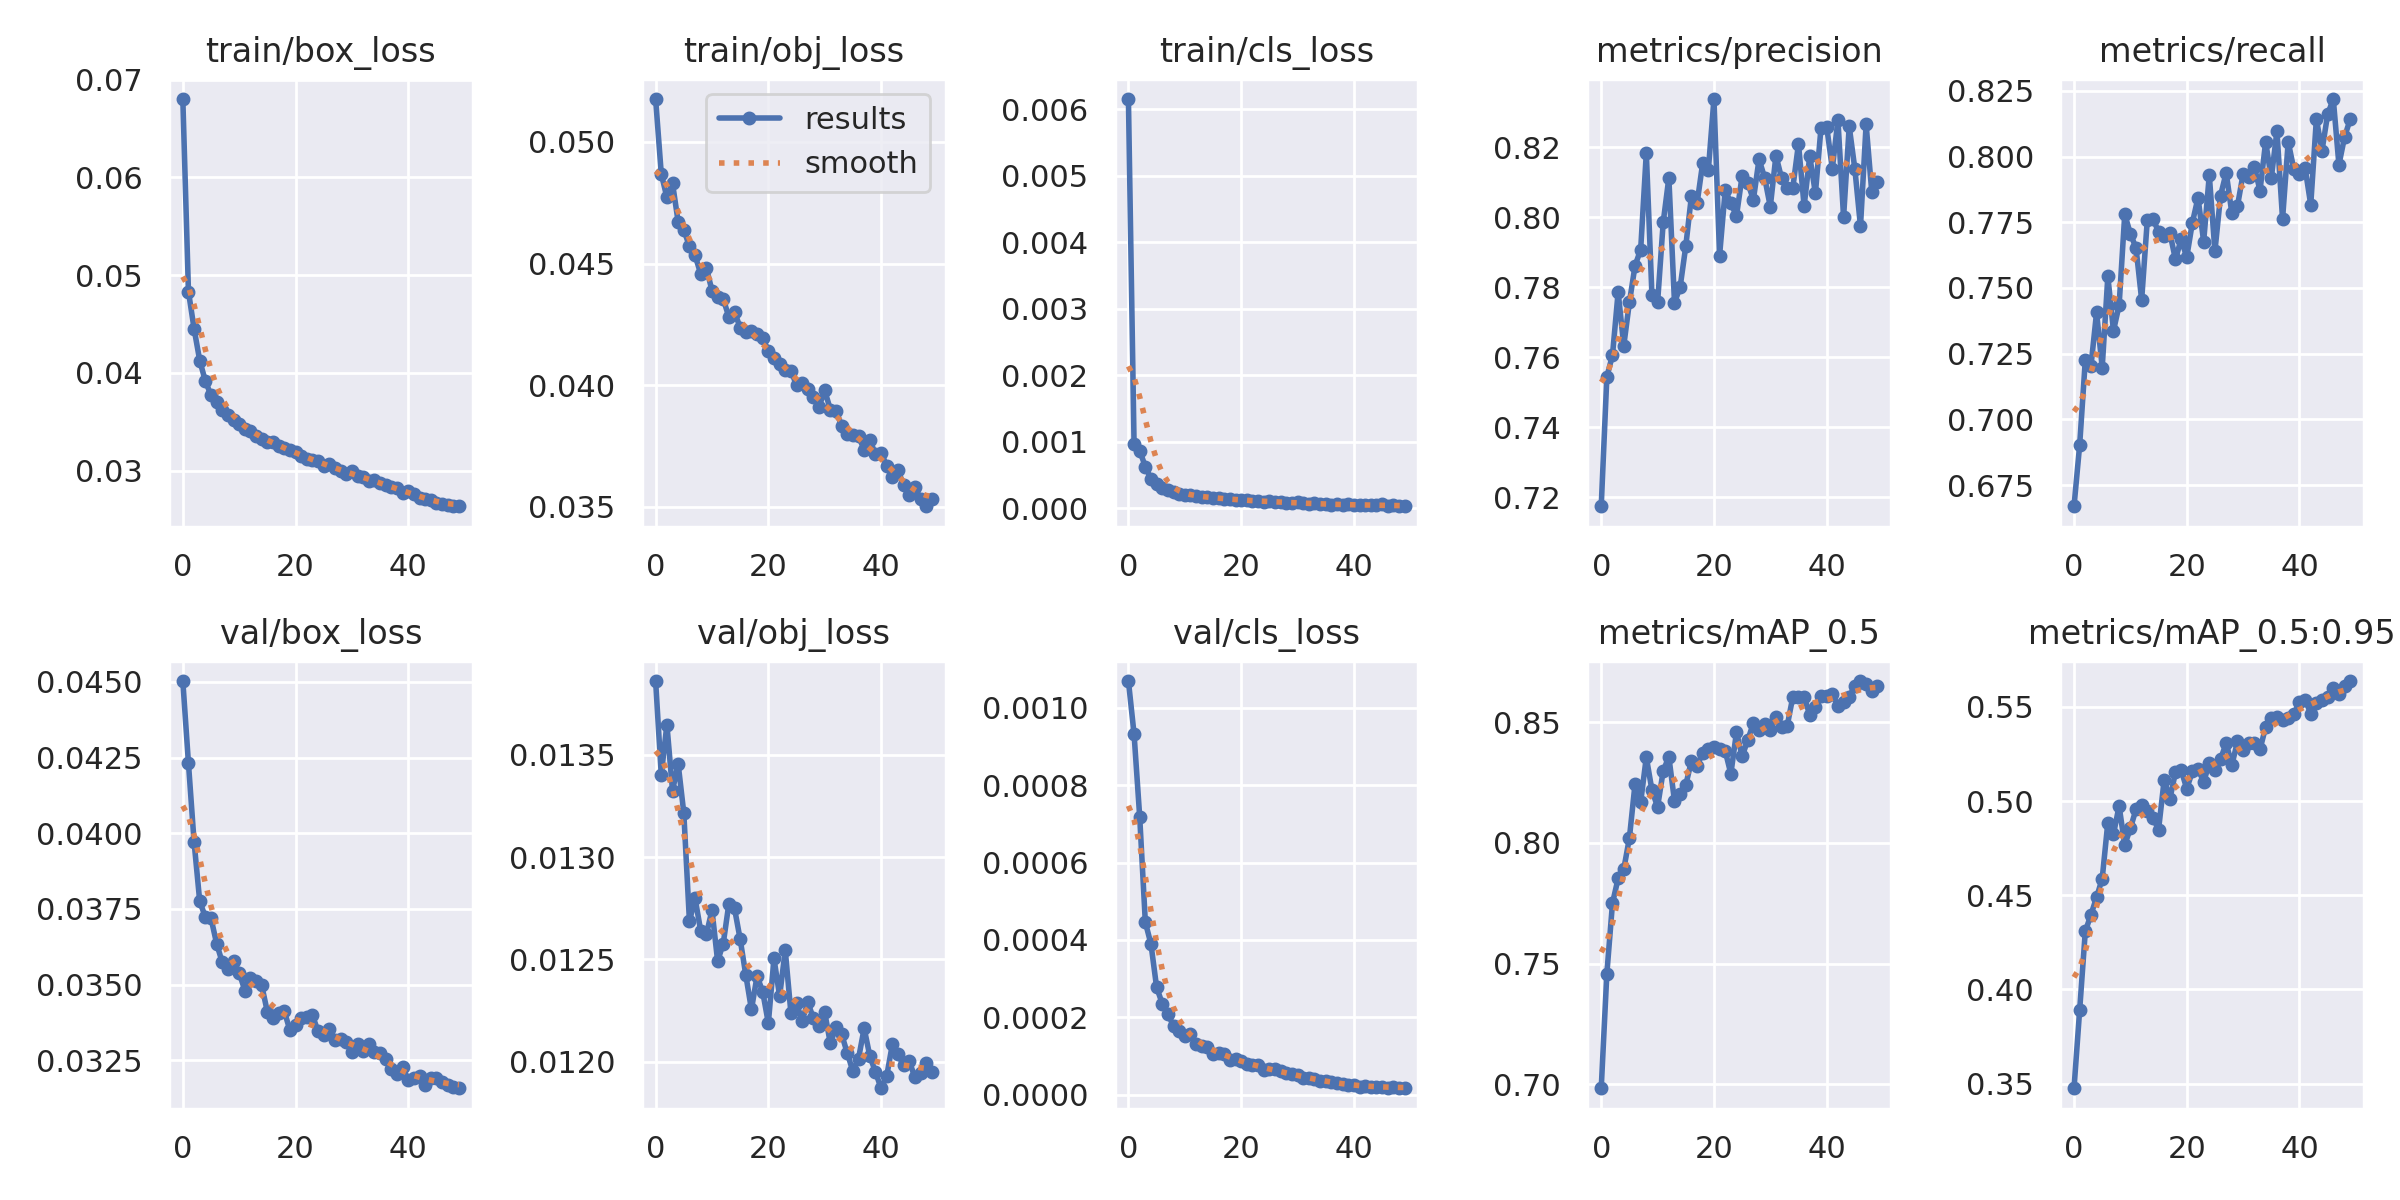

In [ ]:
#displaying the result of the trained model
from IPython.display import Image
Image(filename='runs/train/exp/results.png', width=800)


Copying the model (best.pt, data.yaml and dataset into the drive)

In [ ]:
!cp /content/yolov5/runs/train/exp*/weights/best.pt /content/drive/MyDrive/chicken_detection_best.pt


In [ ]:
!cp /content/yolov5/chicken-5/data.yaml /content/drive/MyDrive/chicken_data.yaml


In [ ]:
!zip -r /content/drive/MyDrive/dataset.zip chicken-5/


Streaming output truncated to the last 5000 lines.
  adding: chicken-5/train/images/c51aa8886507de15c15d3019cfb379efb8f448f67dbf901cafd9b8532f011412d0a1728_1920_jpg.rf.8f29591e97074412f2340659eea6a303.jpg (deflated 0%)
  adding: chicken-5/train/images/photo-1693792350987-638eeb161f0e_jpg.rf.b5b944b9ab91bfd393c1d92b656910a9.jpg (deflated 1%)
  adding: chicken-5/train/images/bird-3217851_1280_jpg.rf.5a462bf5fafe45c4f8157bfb31ffd346.jpg (deflated 0%)
  adding: chicken-5/train/images/360_F_707071188_0wNOTpm94q6Kno4DFrYiCa7Abjb66Cmk2_jpg.rf.bb55b98229c48b5dd7b60dd2c11fe0dc.jpg (deflated 0%)
  adding: chicken-5/train/images/photo-1738904407376-93b99a6ff8cf_jpg.rf.b447f5d61eee7211fb53ecdc36de44ce.jpg (deflated 0%)
  adding: chicken-5/train/images/photo-1690667898416-d1d4682dd578_jpg.rf.10282560610ec427481485d4751ff63a.jpg (deflated 0%)
  adding: chicken-5/train/images/farmer-holding-chicken-in-front-of-red-barn_jpg.rf.dd9220739ad0e909119ef2fae3f44069.jpg (deflated 0%)
  adding: chicken-5/trai

In [ ]:
#running detection on new image
!python detect.py --weights runs/train/exp/weights/best.pt --img 416 --source /content/drive/MyDrive/sample.jpg


detect: weights=['runs/train/exp/weights/best.pt'], source=/content/drive/MyDrive/sample.jpg, data=data/coco128.yaml, imgsz=[416, 416], conf_thres=0.25, iou_thres=0.45, max_det=1000, device=, view_img=False, save_txt=False, save_format=0, save_csv=False, save_conf=False, save_crop=False, nosave=False, classes=None, agnostic_nms=False, augment=False, visualize=False, update=False, project=runs/detect, name=exp, exist_ok=False, line_thickness=3, hide_labels=False, hide_conf=False, half=False, dnn=False, vid_stride=1
YOLOv5 🚀 v7.0-422-g2540fd4c Python-3.11.13 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)

Fusing layers... 
Model summary: 157 layers, 7015519 parameters, 0 gradients, 15.8 GFLOPs
image 1/1 /content/drive/MyDrive/sample.jpg: 320x416 1 Chicken, 28.6ms
Speed: 0.4ms pre-process, 28.6ms inference, 163.9ms NMS per image at shape (1, 3, 416, 416)
Results saved to runs/detect/exp2


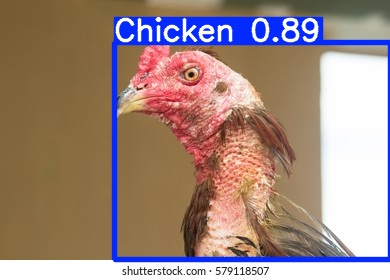

In [ ]:
from IPython.display import Image, display
display(Image(filename='/content/yolov5/runs/detect/exp2/sample.jpg'))


In [ ]:
!python detect.py --weights runs/train/exp/weights/best.pt --img 416 --source /content/group.jpg


detect: weights=['runs/train/exp/weights/best.pt'], source=/content/group.jpg, data=data/coco128.yaml, imgsz=[416, 416], conf_thres=0.25, iou_thres=0.45, max_det=1000, device=, view_img=False, save_txt=False, save_format=0, save_csv=False, save_conf=False, save_crop=False, nosave=False, classes=None, agnostic_nms=False, augment=False, visualize=False, update=False, project=runs/detect, name=exp, exist_ok=False, line_thickness=3, hide_labels=False, hide_conf=False, half=False, dnn=False, vid_stride=1
YOLOv5 🚀 v7.0-422-g2540fd4c Python-3.11.13 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)

Fusing layers... 
Model summary: 157 layers, 7015519 parameters, 0 gradients, 15.8 GFLOPs
image 1/1 /content/group.jpg: 224x416 5 Chickens, 33.5ms
Speed: 0.4ms pre-process, 33.5ms inference, 151.0ms NMS per image at shape (1, 3, 416, 416)
Results saved to runs/detect/exp3


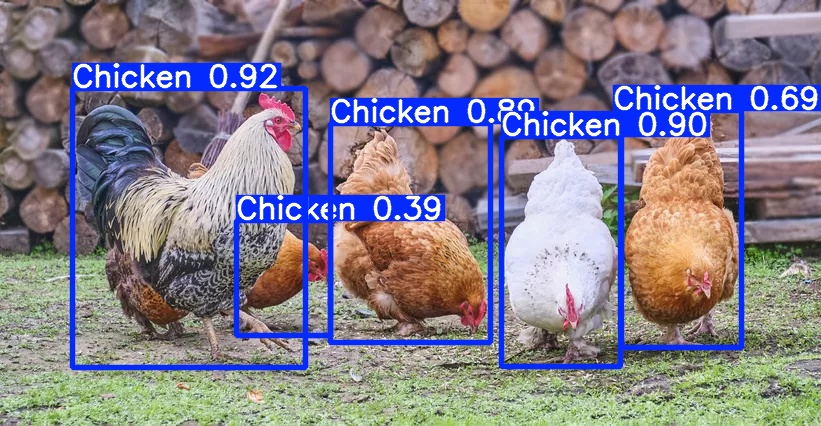

In [ ]:
from IPython.display import Image, display
display(Image(filename='/content/yolov5/runs/detect/exp3/group.jpg'))


In [ ]:
!python detect.py --weights runs/train/exp/weights/best.pt --img 416 --source /content/drive/MyDrive/chicken/images


detect: weights=['runs/train/exp/weights/best.pt'], source=/content/drive/MyDrive/chicken/images, data=data/coco128.yaml, imgsz=[416, 416], conf_thres=0.25, iou_thres=0.45, max_det=1000, device=, view_img=False, save_txt=False, save_format=0, save_csv=False, save_conf=False, save_crop=False, nosave=False, classes=None, agnostic_nms=False, augment=False, visualize=False, update=False, project=runs/detect, name=exp, exist_ok=False, line_thickness=3, hide_labels=False, hide_conf=False, half=False, dnn=False, vid_stride=1
YOLOv5 🚀 v7.0-422-g2540fd4c Python-3.11.13 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)

Fusing layers... 
Model summary: 157 layers, 7015519 parameters, 0 gradients, 15.8 GFLOPs
image 1/55 /content/drive/MyDrive/chicken/images/3218301410_975641fa40_b.jpg: 288x416 1 Chicken, 28.2ms
image 2/55 /content/drive/MyDrive/chicken/images/82pqi6mzhwv91.png: 416x416 8 Chickens, 7.2ms
image 3/55 /content/drive/MyDrive/chicken/images/PreeningHen_271993823-300x297.jpg: 416x416 1 Chic

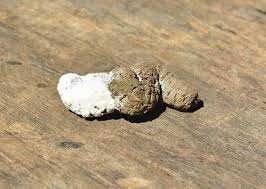

In [ ]:
from IPython.display import Image, display
display(Image(filename='/content/yolov5/runs/detect/exp4/download (3).jpeg'))


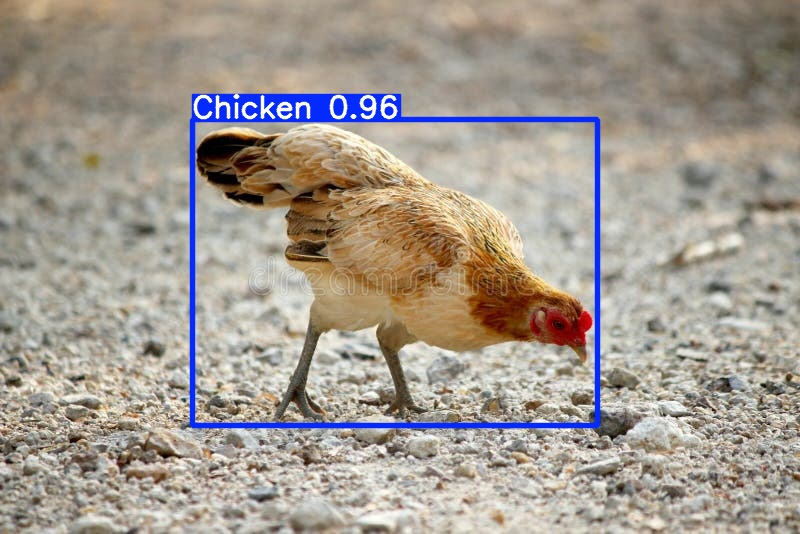

In [ ]:
from IPython.display import Image, display
display(Image(filename='/content/yolov5/runs/detect/exp4/chicken-cock-rooster-countryside-fighting-thailand-112553676.jpg'))


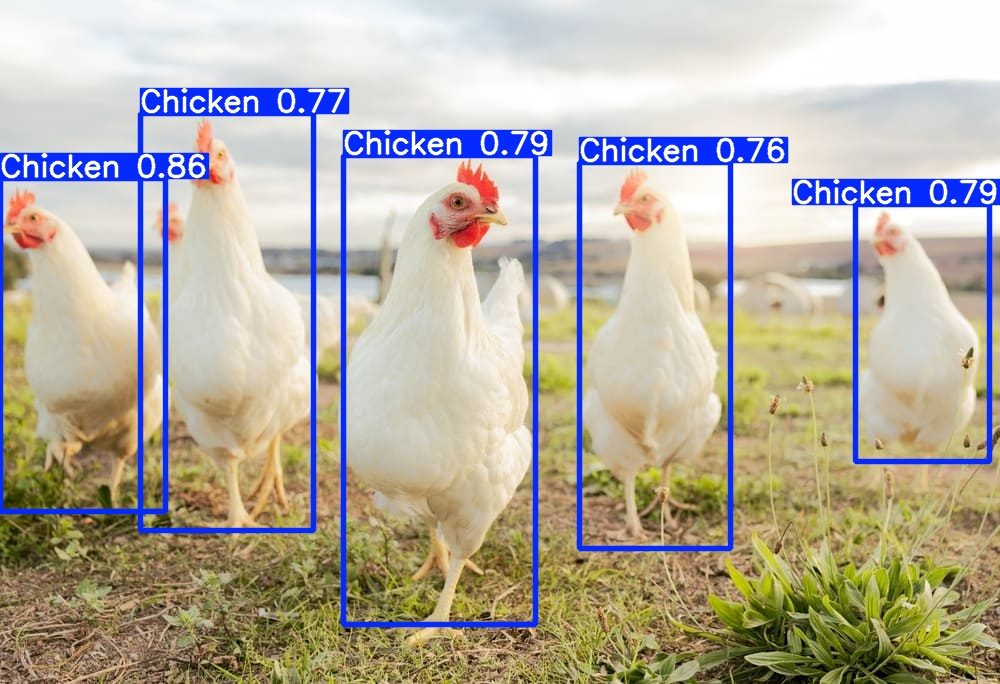

In [ ]:
from IPython.display import Image, display
display(Image(filename='/content/yolov5/runs/detect/exp4/multiple_white_chickens.jpg'))


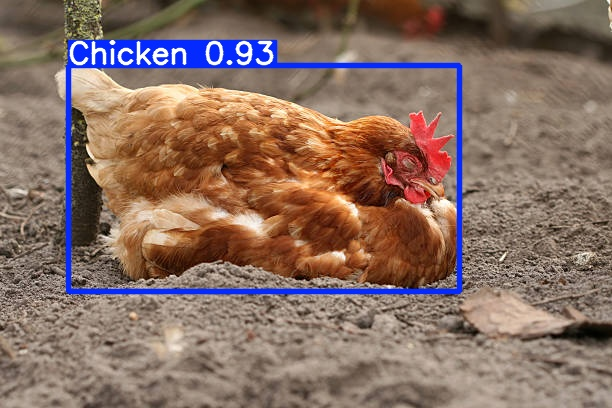

In [ ]:
from IPython.display import Image, display
display(Image(filename='/content/yolov5/runs/detect/exp4/istockphoto-92780855-612x612.jpg'))


In [ ]:
!cp runs/train/exp/results.png /content/drive/MyDrive/training_results.png
!cp runs/train/exp/results.csv /content/drive/MyDrive/results_log.csv


In [ ]:
import pandas as pd

df = pd.read_csv('runs/train/exp/results.csv')
print(df.columns.tolist())


['               epoch', '      train/box_loss', '      train/obj_loss', '      train/cls_loss', '   metrics/precision', '      metrics/recall', '     metrics/mAP_0.5', 'metrics/mAP_0.5:0.95', '        val/box_loss', '        val/obj_loss', '        val/cls_loss', '               x/lr0', '               x/lr1', '               x/lr2']


In [ ]:
import pandas as pd

# Load and clean column names
df = pd.read_csv('runs/train/exp/results.csv')
df.columns = df.columns.str.strip()  # remove leading/trailing spaces

# Now you can access them normally
print(df[['metrics/precision', 'metrics/recall', 'metrics/mAP_0.5', 'metrics/mAP_0.5:0.95']].tail())


    metrics/precision  metrics/recall  metrics/mAP_0.5  metrics/mAP_0.5:0.95
45            0.81380         0.81604          0.86514               0.55516
46            0.79737         0.82189          0.86713               0.55971
47            0.82651         0.79687          0.86604               0.55672
48            0.80726         0.80741          0.86286               0.56083
49            0.80992         0.81420          0.86522               0.56365
